# HomeChem Study

In [1]:
import numpy as np
import pandas as pd
from metvae.model import MetVAE
import torch
import seaborn as sns
import random

import matplotlib.pyplot as plt
%matplotlib inline

## Data import

In [2]:
df_ms1 = pd.read_csv('../data/homechem/homechem_ms1.csv', index_col=0)
df_ms1.index = df_ms1.index.astype(str)
smd = pd.read_table('../data/homechem/homechem_sample_metadata.tsv', index_col=0)
smd.sort_index(inplace=True)
smd.index = smd.index.astype(str)
fmd_ms2 = pd.read_table('../data/homechem/homechem_ms2.tsv')
fmd_ms2 = fmd_ms2.set_index('#Scan#')
fmd_ms2.index = fmd_ms2.index.astype(str)

print('data shape:', df_ms1.shape)
print('sample metadata shape:', smd.shape)
print('feature metadata (MS2) shape:', fmd_ms2.shape)

data shape: (26928, 612)
sample metadata shape: (602, 16)
feature metadata (MS2) shape: (2536, 45)


## Data preprocessing

In [3]:
fmd_ms1 = df_ms1[['row m/z', 'row retention time']]

# Filter columns that end with "Peak area"
peak_area_cols = [col for col in df_ms1.columns if col.endswith(" Peak area")]
df_abundance = df_ms1[peak_area_cols]
# Rename the columns to remove " Peak area" suffix
new_column_names = {col: col.split(' ')[0] for col in df_abundance.columns}
df_abundance = df_abundance.rename(columns=new_column_names)

print('Proportion of zeros: ', np.round((df_abundance == 0).sum().sum()/df_abundance.size*100), '%')

Proportion of zeros:  86.0 %


In [4]:
print(smd['ATTRIBUTE_timepoint'].value_counts())

smd_t2 = smd[smd['ATTRIBUTE_timepoint']=='T2']

ATTRIBUTE_timepoint
T1       264
T2       264
Blank     74
Name: count, dtype: int64


In [5]:
# After T1, the house was used for the House Observations of Microbial and Environmental Chemistry (HOMEChem) field campaign

# Subset to samples at T2
samp_ids = set(smd_t2.index).intersection(df_abundance.columns)
df_abundance = df_abundance[list(samp_ids)]
df_abundance = df_abundance.loc[:, ~df_abundance.columns.duplicated()]
smd_t2 = smd_t2[smd_t2.index.isin(list(samp_ids))]

smd_t2.index = ["S" + str(idx) for idx in smd_t2.index]
df_abundance.columns = ["S" + str(col) for col in df_abundance.columns]

In [6]:
zero_percentage = (df_abundance == 0).mean(axis=1)
df_abundance = df_abundance[zero_percentage <= 0.3]

print('Proportion of zeros: ', np.round((df_abundance == 0).sum().sum()/df_abundance.size*100), '%')
print('data shape:', df_abundance.shape)
print('sample metadata shape:', smd_t2.shape)
print('feature metadata (MS2) shape:', fmd_ms2.shape)

Proportion of zeros:  9.0 %
data shape: (2516, 264)
sample metadata shape: (264, 16)
feature metadata (MS2) shape: (2536, 45)


## Run MetVAE

In [7]:
max_epochs=1000
learning_rate=1e-2
d, n = df_abundance.shape
latent_dim = min(n, d)

model = MetVAE(data=df_abundance,
               features_as_rows=True,
               latent_dim=latent_dim,
               use_gpu=False,
               seed=0)

model.train(batch_size=100,
            num_workers=0,
            max_epochs=max_epochs,
            learning_rate=learning_rate,
            log_every_n_steps=1)

Start: samples=264, features=2516
Filtered features: removed 0 (threshold 0.30)
Filtered samples: none (no sample_zero_threshold provided)
After zero filtering: samples=264, features=2516
Post-cleaning (convert negative values to zeros and drop all-zero samples): samples=264, features=2516


100%|██████████| 1000/1000 [02:20<00:00,  7.13it/s]


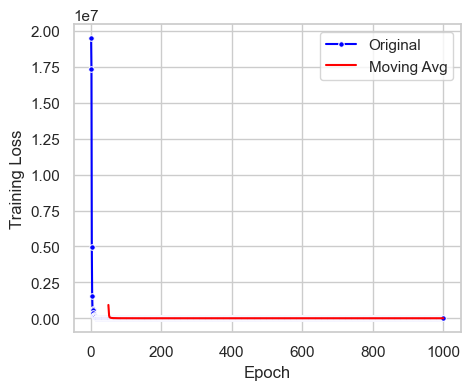

In [8]:
df_loss = pd.DataFrame({
    'Epoch': range(1, max_epochs+1),
    'Training Loss': model.train_loss
})
# Get the initial loss
init_loss = df_loss['Training Loss'].iloc[0]
# Keep only rows where loss is less than or equal to initial loss to facilitate the visualization
df_loss = df_loss[df_loss['Training Loss'] <= init_loss]

window_size = 50
df_loss['MA Training Loss'] = df_loss['Training Loss'].rolling(window=window_size).mean()
df_loss.replace([np.inf, -np.inf], np.nan, inplace=True)

plt.figure(figsize=(5, 4))
sns.set_theme(style="whitegrid")   
sns.lineplot(data=df_loss, x='Epoch', y='Training Loss', marker='o', markersize=4, color='blue', label='Original')
sns.lineplot(data=df_loss, x='Epoch', y='MA Training Loss', color='red', label='Moving Avg')
plt.show()

In [9]:
model.get_corr(num_sim=100, workers=-1, seed=0);
results_metvae = model.sparse_by_p(p_adj_method='fdr_bh', cutoff=0.01)
est_cor = results_metvae['sparse_estimate'].values

df_cor = pd.DataFrame(
    est_cor,
    index=df_abundance.index,
    columns=df_abundance.index
)

# Get upper triangle mask (excluding diagonal)
df_cor.index.name = None
df_cor.columns.name = None

mask = np.triu(np.ones(df_cor.shape), k=1).astype(bool)
df_cor_upper = df_cor.where(mask)

# Convert to long format
df_long = df_cor_upper.stack().reset_index()
df_long.columns = ['node1', 'node2', 'correlation']

# Sort by correlations
df_long = df_long.sort_values('correlation', key=abs, ascending=False)
df_long.to_csv('../results/intermediate_results/homechem_correlations.csv', index=False)

## Prepare the graph

In [1]:
import re
import os
import numpy as np
import pandas as pd
import networkx as nx

### Import the original graph

In [2]:
G_cosine_full = nx.read_graphml("../data/homechem/homechem_graph.graphml")

print(G_cosine_full.is_directed())

False


In [3]:
print(f"{G_cosine_full.number_of_nodes()} nodes, {G_cosine_full.number_of_edges()} edges")

# Show edge attributes
edges_cosine_full = nx.to_pandas_edgelist(G_cosine_full)
print("Edge attributes:")
print(list(edges_cosine_full.columns))
print("Cosine score distribution:")
print(edges_cosine_full['cosine_score'].describe())

26928 nodes, 4500976 edges
Edge attributes:
['source', 'target', 'component', 'property1', 'node2', 'explained_intensity', 'node1', 'mass_difference', 'cosine_score', 'EdgeType', 'EdgeScore', 'id', 'EdgeAnnotation']
Cosine score distribution:
count    4.500976e+06
mean     6.807078e-01
std      1.802343e-01
min      1.000000e-01
25%      5.450000e-01
50%      6.672000e-01
75%      8.529000e-01
max      1.000000e+00
Name: cosine_score, dtype: float64


### Create conventional correlation graphs

In [4]:
# Load correlation data
corr_df = pd.read_csv('../results/intermediate_results/homechem_correlations.csv')
corr_df['source'] = corr_df['node1'].astype(str)
corr_df['target'] = corr_df['node2'].astype(str)

corr_df.shape

(3163870, 5)

In [5]:
corr_df['corr_cutoff0.7'] = np.where(corr_df['correlation'].abs() >= 0.7, corr_df['correlation'], 0)
print(f"Number of edges with correlations >= 0.7: {(corr_df['corr_cutoff0.7'] != 0).sum()}")

Number of edges with correlations >= 0.7: 2655


In [6]:
col = 'corr_cutoff0.7'
cutoff_value = col.replace('corr_cutoff', '')
    
# Separate positive and negative edge lists for this cutoff
pos_edges = []
neg_edges = []
for _, row in corr_df.iterrows():
    u, v, c = row["source"], row["target"], float(row[col])
    if c > 0:
        pos_edges.append((u, v, {
            'EdgeScore': c,
            'EdgeType': f'Correlation_pos_cutoff{cutoff_value}',
            'id':       f'Correlation_pos_cutoff{cutoff_value}'
        }))
    elif c < 0:
        neg_edges.append((u, v, {
            'EdgeScore': c,
            'EdgeType': f'Correlation_neg_cutoff{cutoff_value}',
            'id':       f'Correlation_neg_cutoff{cutoff_value}'
        }))

# Build graphs
G_corr_pos = nx.Graph(); G_corr_pos.add_edges_from(pos_edges)
G_corr_neg = nx.Graph(); G_corr_neg.add_edges_from(neg_edges)

# Copy node attributes from the original cosine graph
nodes_updated_pos = 0
for node in G_corr_pos.nodes():
    if node in G_cosine_full.nodes():
        G_corr_pos.nodes[node].update(G_cosine_full.nodes[node])
        nodes_updated_pos += 1

nodes_updated_neg = 0
for node in G_corr_neg.nodes():
    if node in G_cosine_full.nodes():
        G_corr_neg.nodes[node].update(G_cosine_full.nodes[node])
        nodes_updated_neg += 1

print(f"\n{col}: + edges = {G_corr_pos.number_of_edges()}, - edges = {G_corr_neg.number_of_edges()}")
print(f"Updated + node attrs: {nodes_updated_pos} / {G_corr_pos.number_of_nodes()}")
print(f"Updated - node attrs: {nodes_updated_neg} / {G_corr_neg.number_of_nodes()}")

# Save as GraphML (separate files for pos/neg)
out_base = "../results/outputs/homechem_correlation_graph_cutoff"
out_pos = f"{out_base}{cutoff_value}_pos.graphml"
out_neg = f"{out_base}{cutoff_value}_neg.graphml"
nx.write_graphml(G_corr_pos, out_pos)
nx.write_graphml(G_corr_neg, out_neg)
print(f"Saved: {out_pos}")
print(f"Saved: {out_neg}")


corr_cutoff0.7: + edges = 1772, - edges = 883
Updated + node attrs: 445 / 445
Updated - node attrs: 118 / 118
Saved: ../results/outputs/homechem_correlation_graph_cutoff0.7_pos.graphml
Saved: ../results/outputs/homechem_correlation_graph_cutoff0.7_neg.graphml
